In [3]:
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score,classification_report

In [4]:
# Load the dataset
df = pd.read_csv('C:/Users/ragu/capstone_pj/dataset/insurance_data.csv')

In [5]:
# Reading the data
df.head()

,Policy_ID,Customer_Age,Gender,Policy_Type,Annual_Income,Property_Age,Claim_History,Risk_Score,Premium_Amount,Claim_Amount,fraudulent_claim
0,POL100000,56,Female,Health,91465.94,8,2,Medium,426,14134.62,0
1,POL100001,69,Female,Property,99375.03,3,1,Low,552,4075.14,0
2,POL100002,46,Male,Health,79249.71,7,1,Low,356,1382.87,0
3,POL100003,32,Male,Auto,78744.75,15,1,High,628,24902.32,0
4,POL100004,60,Male,Life,51210.11,19,2,High,584,29411.28,1


In [6]:
# make columns lowercase
df.columns = df.columns.str.lower()

In [7]:
#check for null values
df.isnull().sum()

policy_id           0
customer_age        0
gender              0
policy_type         0
annual_income       0
property_age        0
claim_history       0
risk_score          0
premium_amount      0
claim_amount        0
fraudulent_claim    0
dtype: int64

In [8]:
# Check for duplicates
df.duplicated().sum()

0

In [9]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   policy_id         100000 non-null  object 
 1   customer_age      100000 non-null  int64  
 2   gender            100000 non-null  object 
 3   policy_type       100000 non-null  object 
 4   annual_income     100000 non-null  float64
 5   property_age      100000 non-null  int64  
 6   claim_history     100000 non-null  int64  
 7   risk_score        100000 non-null  object 
 8   premium_amount    100000 non-null  int64  
 9   claim_amount      100000 non-null  float64
 10  fraudulent_claim  100000 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 8.4+ MB


In [10]:
# change the dtype for columns
df[["gender", "policy_type", "risk_score"]] = df[["gender", "policy_type", "risk_score"]].astype(object)

In [11]:
# describe the dataset
df.describe()

,customer_age,annual_income,property_age,claim_history,premium_amount,claim_amount,fraudulent_claim
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,43.500270,60005.893630,9.509020,1.200650,519.592040,19161.815148,0.242510
std,14.970933,19691.895922,5.772903,1.092209,96.429391,11647.972285,0.428603
min,18.000000,15000.000000,0.000000,0.000000,300.000000,0.000000,0.000000
25%,31.000000,46513.822500,4.000000,0.000000,448.000000,7053.422500,0.000000
50%,43.000000,59922.690000,10.000000,1.000000,526.000000,20915.970000,0.000000
75%,56.000000,73378.797500,15.000000,2.000000,596.000000,29958.755000,0.000000
max,69.000000,152334.530000,19.000000,10.000000,702.000000,41740.810000,1.000000


In [12]:
# describe the dataset
df.describe(include="object")

,policy_id,gender,policy_type,risk_score
count,100000,100000,100000,100000
unique,100000,2,4,3
top,POL100000,Female,Auto,High
freq,1,50201,30084,49653


In [13]:
#Eploratory Data Analysis

<Axes: xlabel='risk_score', ylabel='Count'>

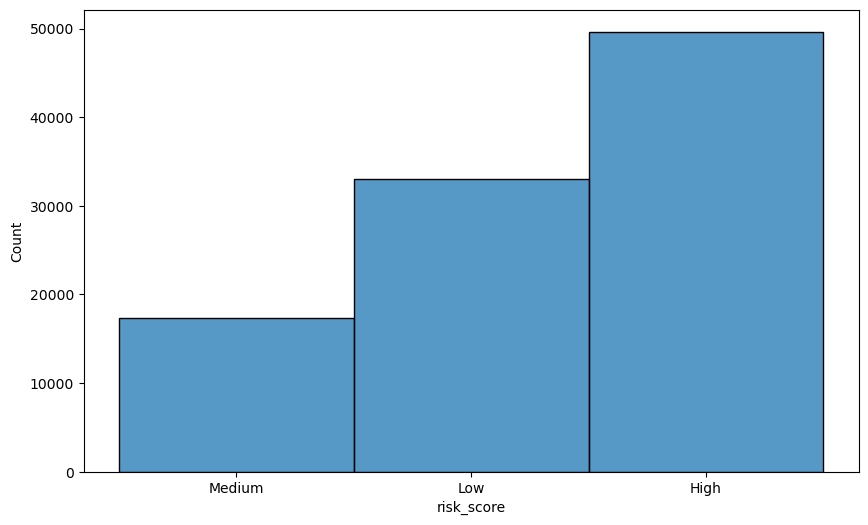

In [14]:
# Univariate Analysis for Target 
plt.figure(figsize=(10, 6))
sns.histplot(df["risk_score"])

<Axes: xlabel='customer_age', ylabel='Count'>

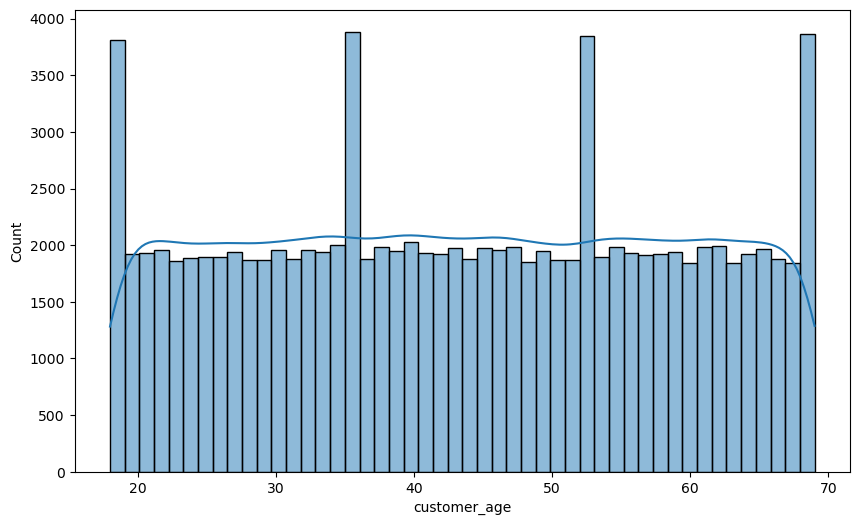

In [15]:
# Check for customer age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["customer_age"], kde=True)

<Axes: xlabel='gender', ylabel='count'>

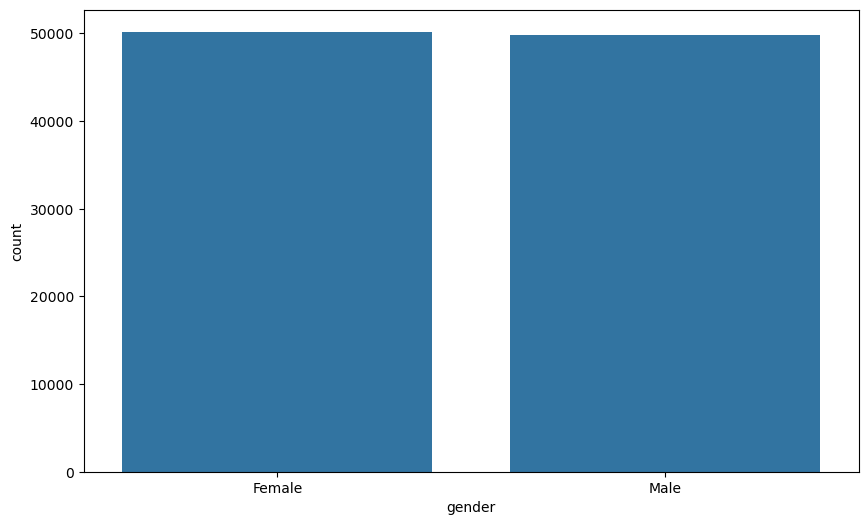

In [16]:
# Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=df["gender"])

<Axes: xlabel='policy_type', ylabel='count'>

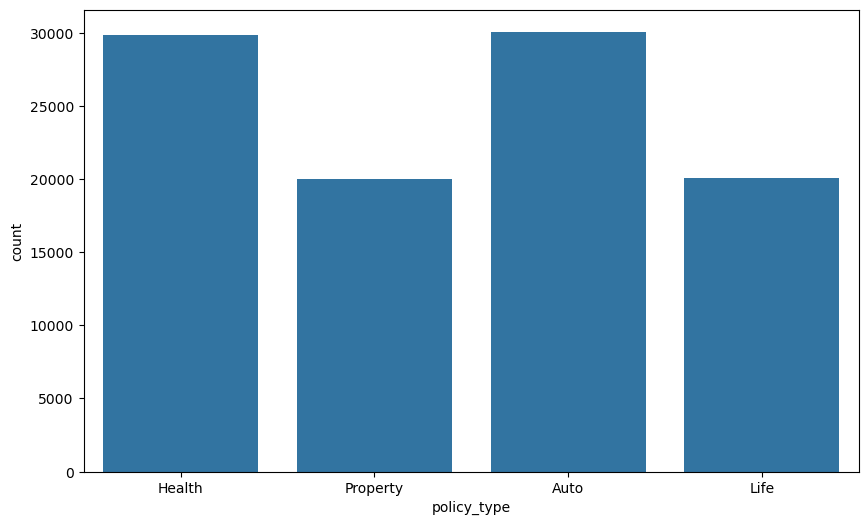

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="policy_type")

<Axes: xlabel='annual_income', ylabel='Count'>

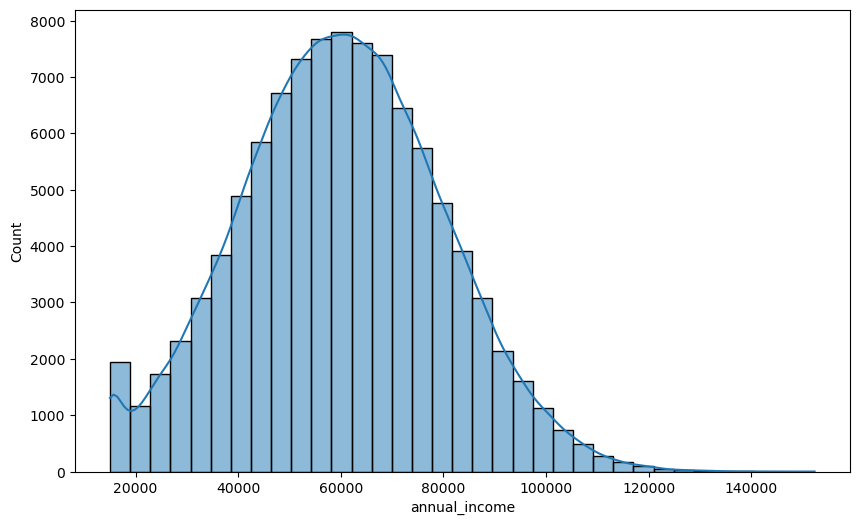

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df["annual_income"], bins=35, kde=True)

<Axes: xlabel='property_age', ylabel='Count'>

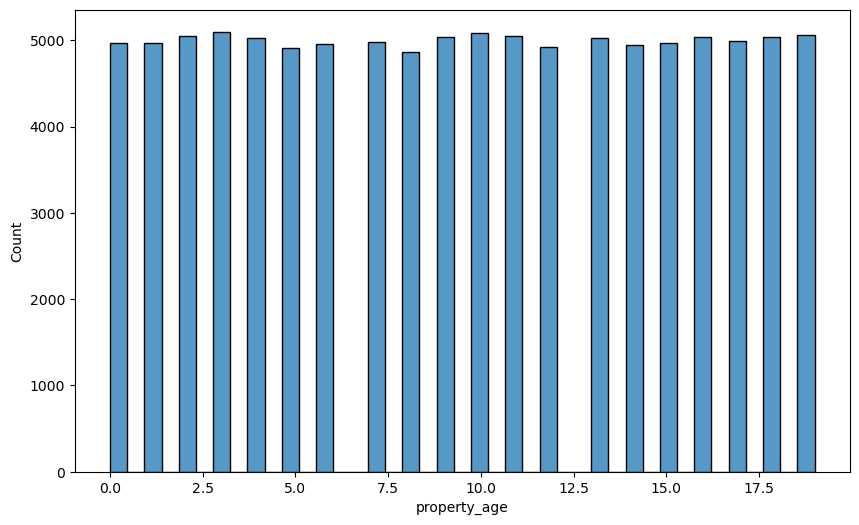

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df["property_age"])

<Axes: xlabel='premium_amount', ylabel='Count'>

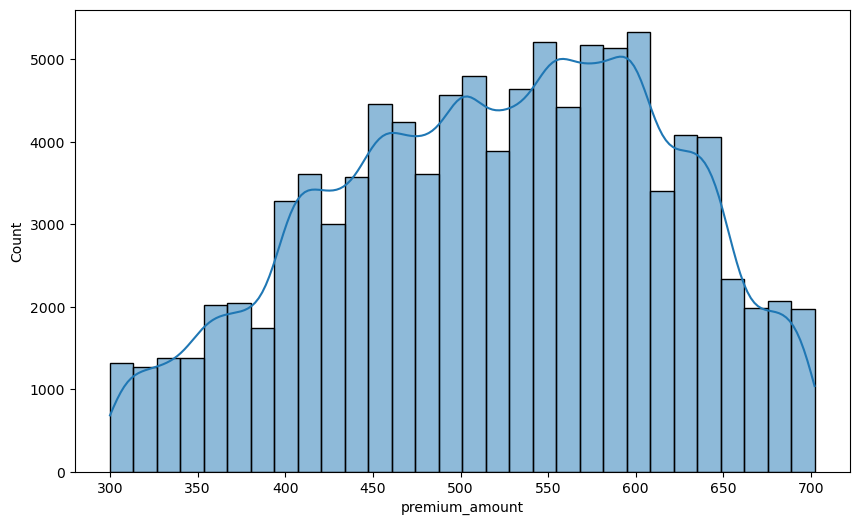

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(df["premium_amount"], bins=30, kde=True)

<Axes: xlabel='claim_amount', ylabel='Count'>

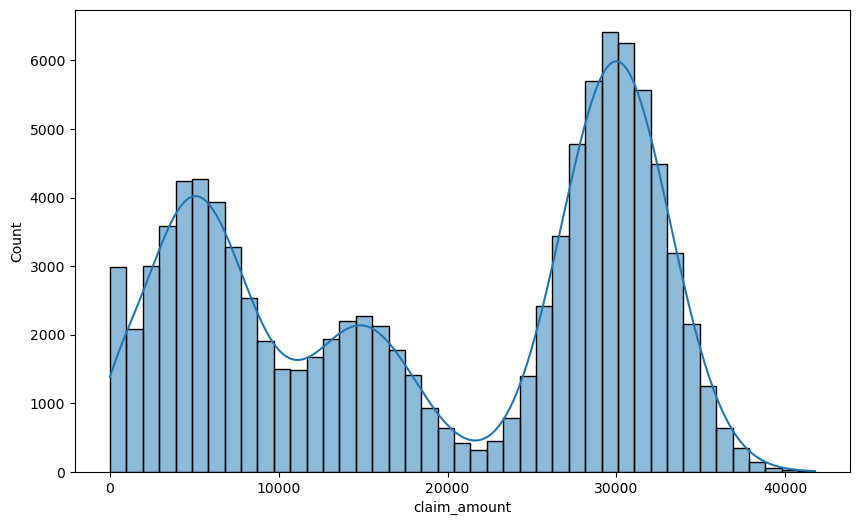

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df["claim_amount"], kde=True)

<Axes: xlabel='risk_score', ylabel='count'>

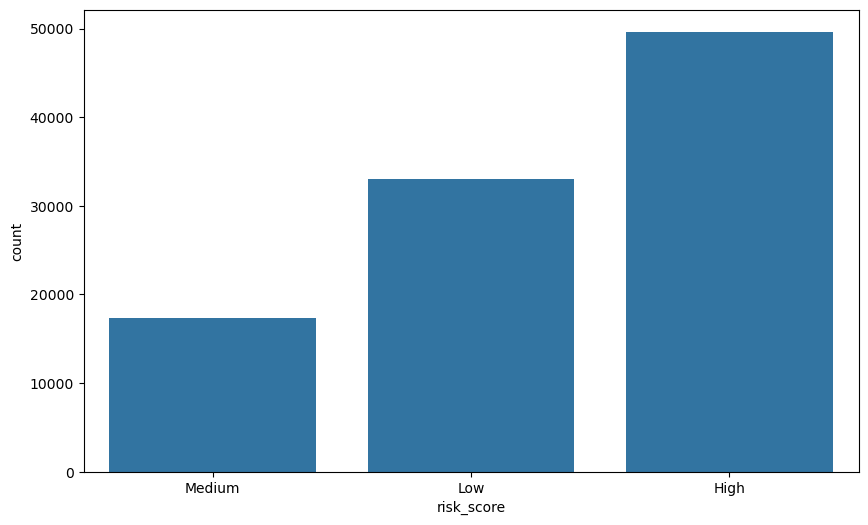

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df["risk_score"])

<Axes: xlabel='risk_score', ylabel='count'>

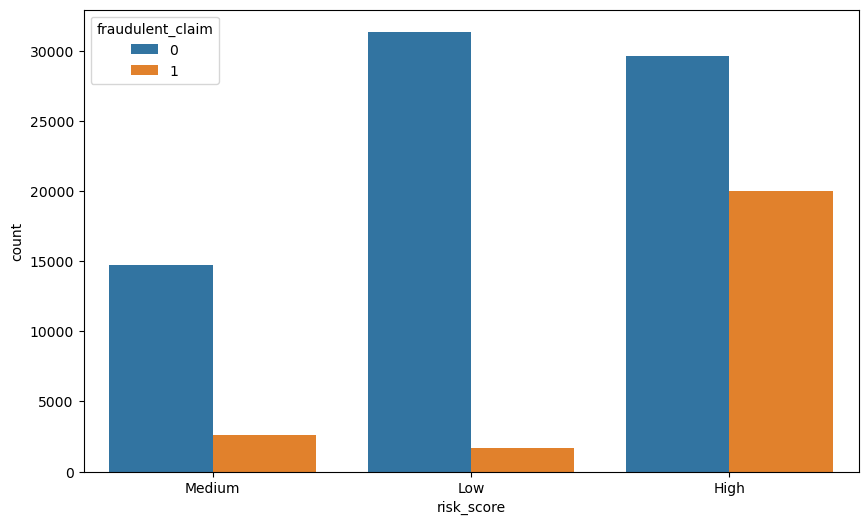

In [23]:
# Bivariate analysis
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="risk_score", hue="fraudulent_claim")

<Axes: xlabel='policy_type', ylabel='count'>

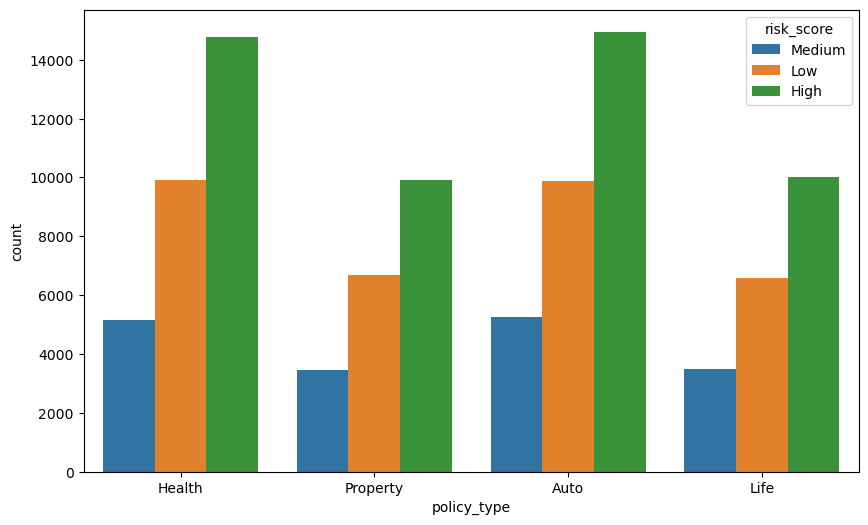

In [24]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="policy_type", hue="risk_score")

<Axes: xlabel='risk_score', ylabel='annual_income'>

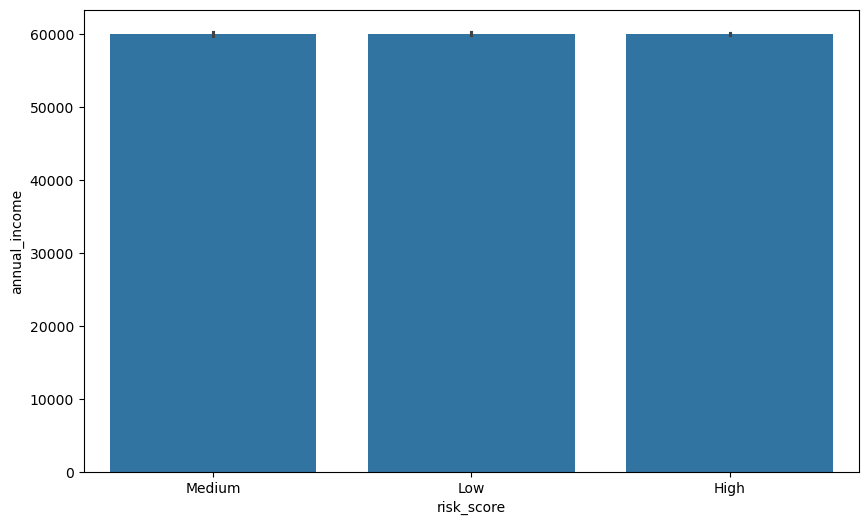

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="risk_score", y="annual_income")

<Figure size 1000x600 with 0 Axes>

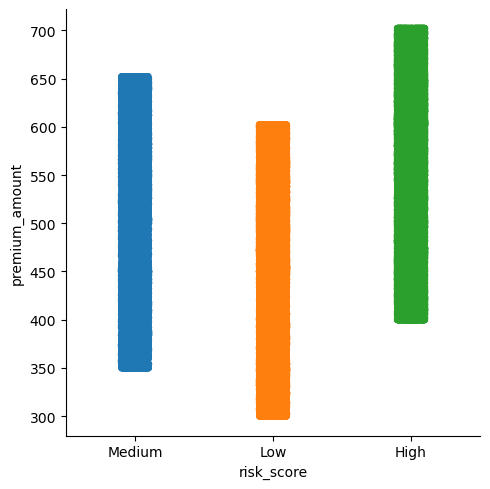

In [26]:
plt.figure(figsize=(10, 6))
sns.catplot(data=df, x="risk_score", y="premium_amount", hue="risk_score")

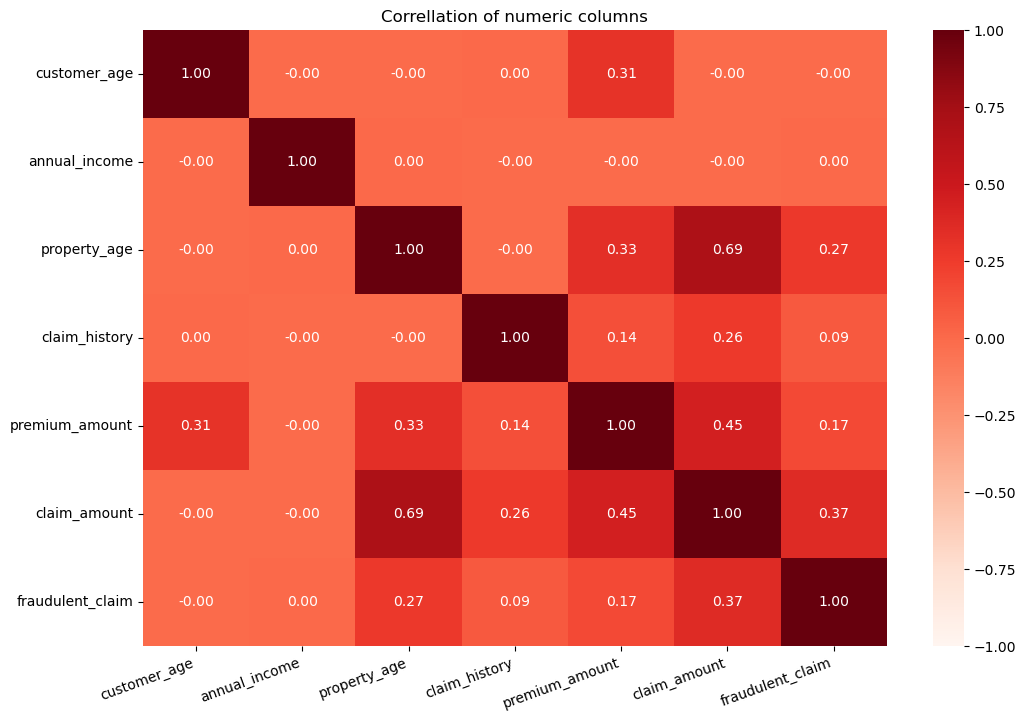

In [27]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, fmt=".2f", vmin=-1, vmax=1,cmap="Reds")
plt.title("Correllation of numeric columns")
plt.xticks(rotation=20,ha="right")
plt.show()

In [28]:
#One hot encoding

encode = df[["gender", "policy_type"]]
one_hot_encode = pd.get_dummies(encode,columns=["gender", "policy_type"], drop_first=True).astype(int)

In [29]:
# Label Encoding 

df["risk_score"] = LabelEncoder().fit_transform(df["risk_score"])

In [30]:
# drop columns & insert the one hot encoded columns

df1 = df.drop(columns=["gender", "policy_type"],inplace=True)
df1 = pd.concat([df,one_hot_encode], axis=1)

In [31]:
df1.head()

,policy_id,customer_age,annual_income,property_age,claim_history,risk_score,premium_amount,claim_amount,fraudulent_claim,gender_Male,policy_type_Health,policy_type_Life,policy_type_Property
0,POL100000,56,91465.94,8,2,2,426,14134.62,0,0,1,0,0
1,POL100001,69,99375.03,3,1,1,552,4075.14,0,0,0,0,1
2,POL100002,46,79249.71,7,1,1,356,1382.87,0,1,1,0,0
3,POL100003,32,78744.75,15,1,0,628,24902.32,0,1,0,0,0
4,POL100004,60,51210.11,19,2,0,584,29411.28,1,1,0,1,0


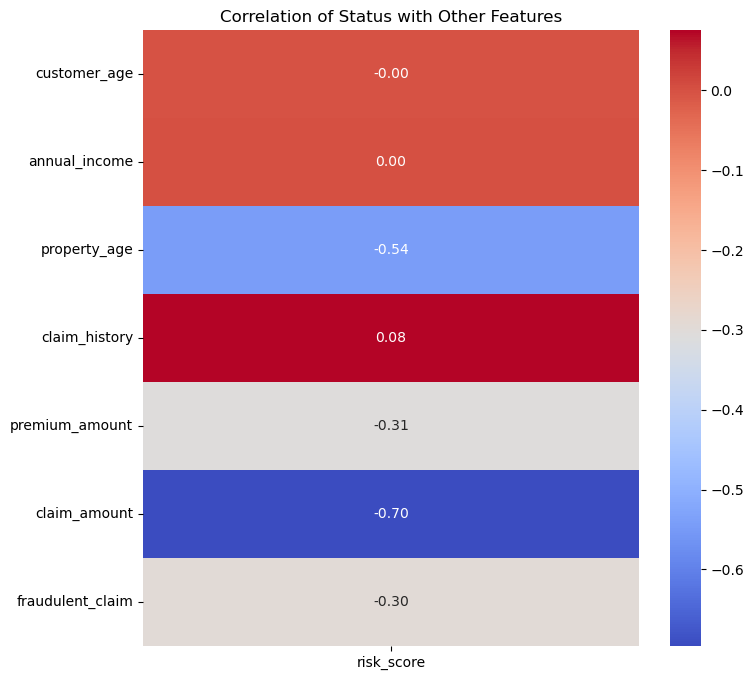

In [32]:
# Compute correlation of "Risk_score" with all other columns 
df2 = df.drop(columns=["policy_id"])
correlation_matrix = df2.corr()[["risk_score"]].drop(index="risk_score")

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Status with Other Features")
plt.show()

In [33]:
# Selected features based on Correlation matrix
# claim_amount, property_age, premium_amount, fraudulent_claim, customer_age, annual_income.

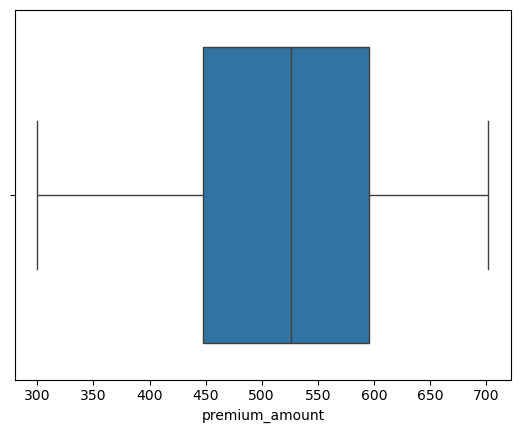

In [34]:
#finding outliers (NO Outliers)
sns.boxplot(x=df['premium_amount'])  
plt.show()

In [35]:
df1.head()

,policy_id,customer_age,annual_income,property_age,claim_history,risk_score,premium_amount,claim_amount,fraudulent_claim,gender_Male,policy_type_Health,policy_type_Life,policy_type_Property
0,POL100000,56,91465.94,8,2,2,426,14134.62,0,0,1,0,0
1,POL100001,69,99375.03,3,1,1,552,4075.14,0,0,0,0,1
2,POL100002,46,79249.71,7,1,1,356,1382.87,0,1,1,0,0
3,POL100003,32,78744.75,15,1,0,628,24902.32,0,1,0,0,0
4,POL100004,60,51210.11,19,2,0,584,29411.28,1,1,0,1,0


In [36]:
# Split the data into features(X) and target variable(y) 
X = df1.drop(columns=["policy_id", "risk_score"])
y = df1["risk_score"]

In [37]:
# Scaling the data (standard scalar)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
X.head()

,customer_age,annual_income,property_age,claim_history,premium_amount,claim_amount,fraudulent_claim,gender_Male,policy_type_Health,policy_type_Life,policy_type_Property
0,56,91465.94,8,2,426,14134.62,0,0,1,0,0
1,69,99375.03,3,1,552,4075.14,0,0,0,0,1
2,46,79249.71,7,1,356,1382.87,0,1,1,0,0
3,32,78744.75,15,1,628,24902.32,0,1,0,0,0
4,60,51210.11,19,2,584,29411.28,1,1,0,1,0


In [39]:
type(X_scaled)

numpy.ndarray

In [40]:
# Change array to dataframe
X = pd.DataFrame(X_scaled, columns=X.columns)
type(X)

pandas.core.frame.DataFrame

In [41]:
# Checking the data types of X and y
type(X)

pandas.core.frame.DataFrame

In [42]:
X.head()

,customer_age,annual_income,property_age,claim_history,premium_amount,claim_amount,fraudulent_claim,gender_Male,policy_type_Health,policy_type_Life,policy_type_Property
0,0.834937,1.597622,-0.261398,0.731869,-0.970581,-0.431596,-0.565817,-0.995988,1.534207,-0.501187,-0.500359
1,1.703291,1.999266,-1.127518,-0.183711,0.336081,-1.295225,-0.565817,-0.995988,-0.651802,-0.501187,1.998564
2,0.166973,0.977250,-0.434622,-0.183711,-1.696504,-1.526363,-0.565817,1.004028,1.534207,-0.501187,-0.500359
3,-0.768177,0.951607,0.951169,-0.183711,1.124227,0.492835,-0.565817,1.004028,-0.651802,-0.501187,-0.500359
4,1.102123,-0.446672,1.644065,0.731869,0.667932,0.879940,1.767354,1.004028,-0.651802,1.995262,-0.500359


In [43]:
type(y)

pandas.core.series.Series

In [44]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# First model (Random Forest Classifier)
model_1 = RandomForestClassifier()

In [46]:
model_1.fit(X_train, y_train)

RandomForestClassifier()

In [47]:
y_pred = model_1.predict(X_test)

In [48]:
# evaluate the model using metrics
print(f"accuracy score : {accuracy_score(y_test,y_pred):.2f}")
print(f"precision score : {precision_score(y_test,y_pred, average='micro'):.2f}")
print(f"recall score : {recall_score(y_test,y_pred, average='micro'):.2f}")
print(f"f1 score : {f1_score(y_test, y_pred, average='micro'):.2f}")
print(classification_report(y_test, y_pred))

accuracy score : 1.00
precision score : 1.00
recall score : 1.00
f1 score : 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9922
           1       1.00      1.00      1.00      6634
           2       1.00      1.00      1.00      3444

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [50]:
# Create pipeline
model_P = Pipeline([
    ("scaler", scaler),
    ("model", model_1)
])

# Train the pipeline
model_P.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier())])

In [51]:
# Save the entire pipeline
joblib.dump(model_P, "risk_classification2.pkl")

['risk_classification2.pkl']

In [53]:
model = joblib.load("risk_classification2.pkl")
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [ ]:
#model = joblib.load("C:/Users/ragu/capstone_pj/vs/risk_classification.pkl2")
t_1  = [[56,91465.94,2,426,0,0,1,0,0]]
t_11 = [[56,91465.94,8,2,426,14134.62,0,0,1,0,0]]
t_2  = [[69, 99375.03, 3, 1, 552, 4075.14, 0, 0, 0, 0, 1]]
t_21 = [[69,99375.03,3,1,552,4075.14,0,0,0,0,1]]
t_3  = [[32,78744.75,1,628,0,1,0,0,0]]
t_31 = [[32,78744.75,15,1,628,24902.32,0,1,0,0,0]]

#prediction = model.predict(t_31)

#print("Prediction:", prediction)

Prediction: [0]


c:\Users\ragu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


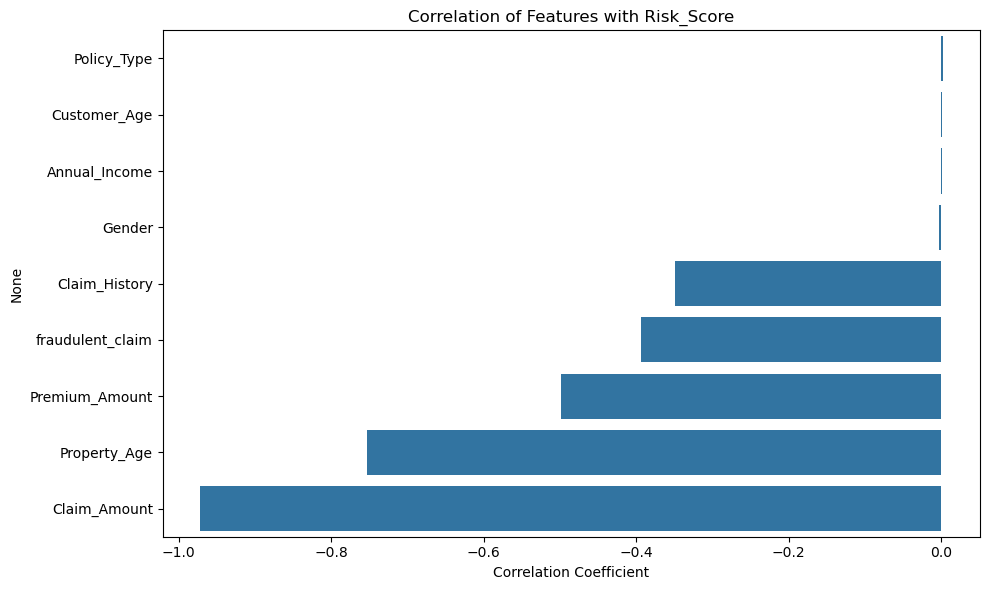

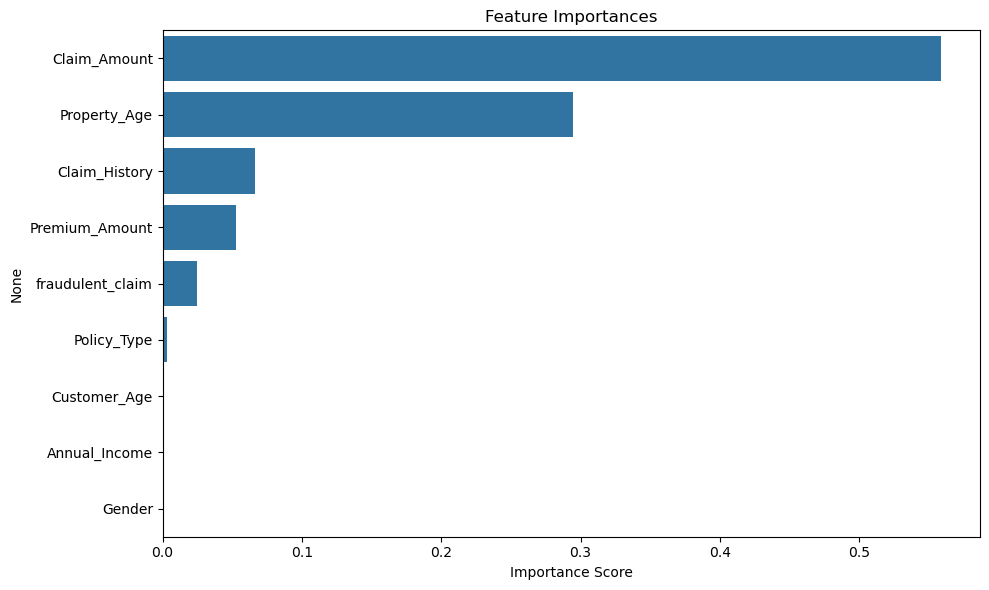

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load your dataset
df3 = pd.read_csv('C:/Users/ragu/capstone_pj/dataset/insurance_data.csv')
df3 = df3[df3['Risk_Score'].isin(['High', 'Low'])].drop(columns=['Policy_ID'])

# Encode categorical variables
for col in ['Gender', 'Policy_Type']:
    le = LabelEncoder()
    df3[col] = le.fit_transform(df3[col])

# Encode target
le_target = LabelEncoder()
df3['Risk_Score'] = le_target.fit_transform(df3['Risk_Score'])  # High = 1, Low = 0

# Correlation with target
correlation = df3.corr(numeric_only=True)
target_corr = correlation['Risk_Score'].drop('Risk_Score').sort_values(ascending=False)

# Plot correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Correlation of Features with Risk_Score")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

# Feature importance using Random Forest
X = df3.drop(columns=['Risk_Score'])
y = df3['Risk_Score']
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [52]:
import pickle
with open("C:/Users/ragu/capstone_pj/vs/risk_classification2.pkl", "rb") as file:
    obj = pickle.load(file)

print(type(obj))

<class 'numpy.ndarray'>
